In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
data_raw = pd.read_csv('data-final.csv', sep='\t')
data = data_raw.copy()
pd.options.display.max_columns = 150

In [3]:
data.drop(data.columns[50:107], axis=1, inplace=True)
data.drop(data.columns[51:], axis=1, inplace=True)

print('Number of participants: ', len(data))
data.head()

Number of participants:  1015341


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,EST1,EST2,EST3,EST4,EST5,EST6,EST7,EST8,EST9,EST10,AGR1,AGR2,AGR3,AGR4,AGR5,AGR6,AGR7,AGR8,AGR9,AGR10,CSN1,CSN2,CSN3,CSN4,CSN5,CSN6,CSN7,CSN8,CSN9,CSN10,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10,country
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,1.0,4.0,4.0,2.0,2.0,2.0,2.0,2.0,3.0,2.0,2.0,5.0,2.0,4.0,2.0,3.0,2.0,4.0,3.0,4.0,3.0,4.0,3.0,2.0,2.0,4.0,4.0,2.0,4.0,4.0,5.0,1.0,4.0,1.0,4.0,1.0,5.0,3.0,4.0,5.0,GB
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,2.0,3.0,4.0,1.0,3.0,1.0,2.0,1.0,3.0,1.0,1.0,4.0,1.0,5.0,1.0,5.0,3.0,4.0,5.0,3.0,3.0,2.0,5.0,3.0,3.0,1.0,3.0,3.0,5.0,3.0,1.0,2.0,4.0,2.0,3.0,1.0,4.0,2.0,5.0,3.0,MY
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,4.0,4.0,4.0,2.0,2.0,2.0,2.0,2.0,1.0,3.0,1.0,4.0,1.0,4.0,2.0,4.0,1.0,4.0,4.0,3.0,4.0,2.0,2.0,2.0,3.0,3.0,4.0,2.0,4.0,2.0,5.0,1.0,2.0,1.0,4.0,2.0,5.0,3.0,4.0,4.0,GB
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,3.0,3.0,3.0,2.0,3.0,2.0,2.0,2.0,4.0,3.0,2.0,4.0,3.0,4.0,2.0,4.0,2.0,4.0,3.0,4.0,2.0,4.0,4.0,4.0,1.0,2.0,2.0,3.0,1.0,4.0,4.0,2.0,5.0,2.0,3.0,1.0,4.0,4.0,3.0,3.0,GB
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,1.0,5.0,5.0,3.0,1.0,1.0,1.0,1.0,3.0,2.0,1.0,5.0,1.0,5.0,1.0,3.0,1.0,5.0,5.0,3.0,5.0,1.0,5.0,1.0,3.0,1.0,5.0,1.0,5.0,5.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,3.0,5.0,5.0,KE


In [4]:
print('Is there any missing value? ', data.isnull().values.any())
print('How many missing values? ', data.isnull().values.sum())


Is there any missing value?  True
How many missing values?  89227


In [5]:
data.dropna(inplace=True)
print('Number of participants after eliminating missing values: ', len(data))

Number of participants after eliminating missing values:  1013481


In [6]:
ext_questions = {'EXT1' : 'I am the life of the party',
                 'EXT2' : 'I dont talk a lot',
                 'EXT3' : 'I feel comfortable around people',
                 'EXT4' : 'I keep in the background',
                 'EXT5' : 'I start conversations',
                 'EXT6' : 'I have little to say',
                 'EXT7' : 'I talk to a lot of different people at parties',
                 'EXT8' : 'I dont like to draw attention to myself',
                 'EXT9' : 'I dont mind being the center of attention',
                 'EXT10': 'I am quiet around strangers'}

est_questions = {'EST1' : 'I get stressed out easily',
                 'EST2' : 'I am relaxed most of the time',
                 'EST3' : 'I worry about things',
                 'EST4' : 'I seldom feel blue',
                 'EST5' : 'I am easily disturbed',
                 'EST6' : 'I get upset easily',
                 'EST7' : 'I change my mood a lot',
                 'EST8' : 'I have frequent mood swings',
                 'EST9' : 'I get irritated easily',
                 'EST10': 'I often feel blue'}

agr_questions = {'AGR1' : 'I feel little concern for others',
                 'AGR2' : 'I am interested in people',
                 'AGR3' : 'I insult people',
                 'AGR4' : 'I sympathize with others feelings',
                 'AGR5' : 'I am not interested in other peoples problems',
                 'AGR6' : 'I have a soft heart',
                 'AGR7' : 'I am not really interested in others',
                 'AGR8' : 'I take time out for others',
                 'AGR9' : 'I feel others emotions',
                 'AGR10': 'I make people feel at ease'}

csn_questions = {'CSN1' : 'I am always prepared',
                 'CSN2' : 'I leave my belongings around',
                 'CSN3' : 'I pay attention to details',
                 'CSN4' : 'I make a mess of things',
                 'CSN5' : 'I get chores done right away',
                 'CSN6' : 'I often forget to put things back in their proper place',
                 'CSN7' : 'I like order',
                 'CSN8' : 'I shirk my duties',
                 'CSN9' : 'I follow a schedule',
                 'CSN10' : 'I am exacting in my work'}

opn_questions = {'OPN1' : 'I have a rich vocabulary',
                 'OPN2' : 'I have difficulty understanding abstract ideas',
                 'OPN3' : 'I have a vivid imagination',
                 'OPN4' : 'I am not interested in abstract ideas',
                 'OPN5' : 'I have excellent ideas',
                 'OPN6' : 'I do not have a good imagination',
                 'OPN7' : 'I am quick to understand things',
                 'OPN8' : 'I use difficult words',
                 'OPN9' : 'I spend time reflecting on things',
                 'OPN10': 'I am full of ideas'}

In [7]:
EXT = [column for column in data if column.startswith('EXT')]
EST = [column for column in data if column.startswith('EST')]
AGR = [column for column in data if column.startswith('AGR')]
CSN = [column for column in data if column.startswith('CSN')]
OPN = [column for column in data if column.startswith('OPN')]

In [8]:
def vis_questions(groupname, questions, color):
    plt.figure(figsize=(50,70))
    for i in range(1, 11):
        plt.subplot(10,5,i)
        plt.hist(data[groupname[i-1]], bins=14, color= color, alpha=.5)
        plt.title(questions[groupname[i-1]], fontsize=20)

Q&As Related to Extroversion Personality


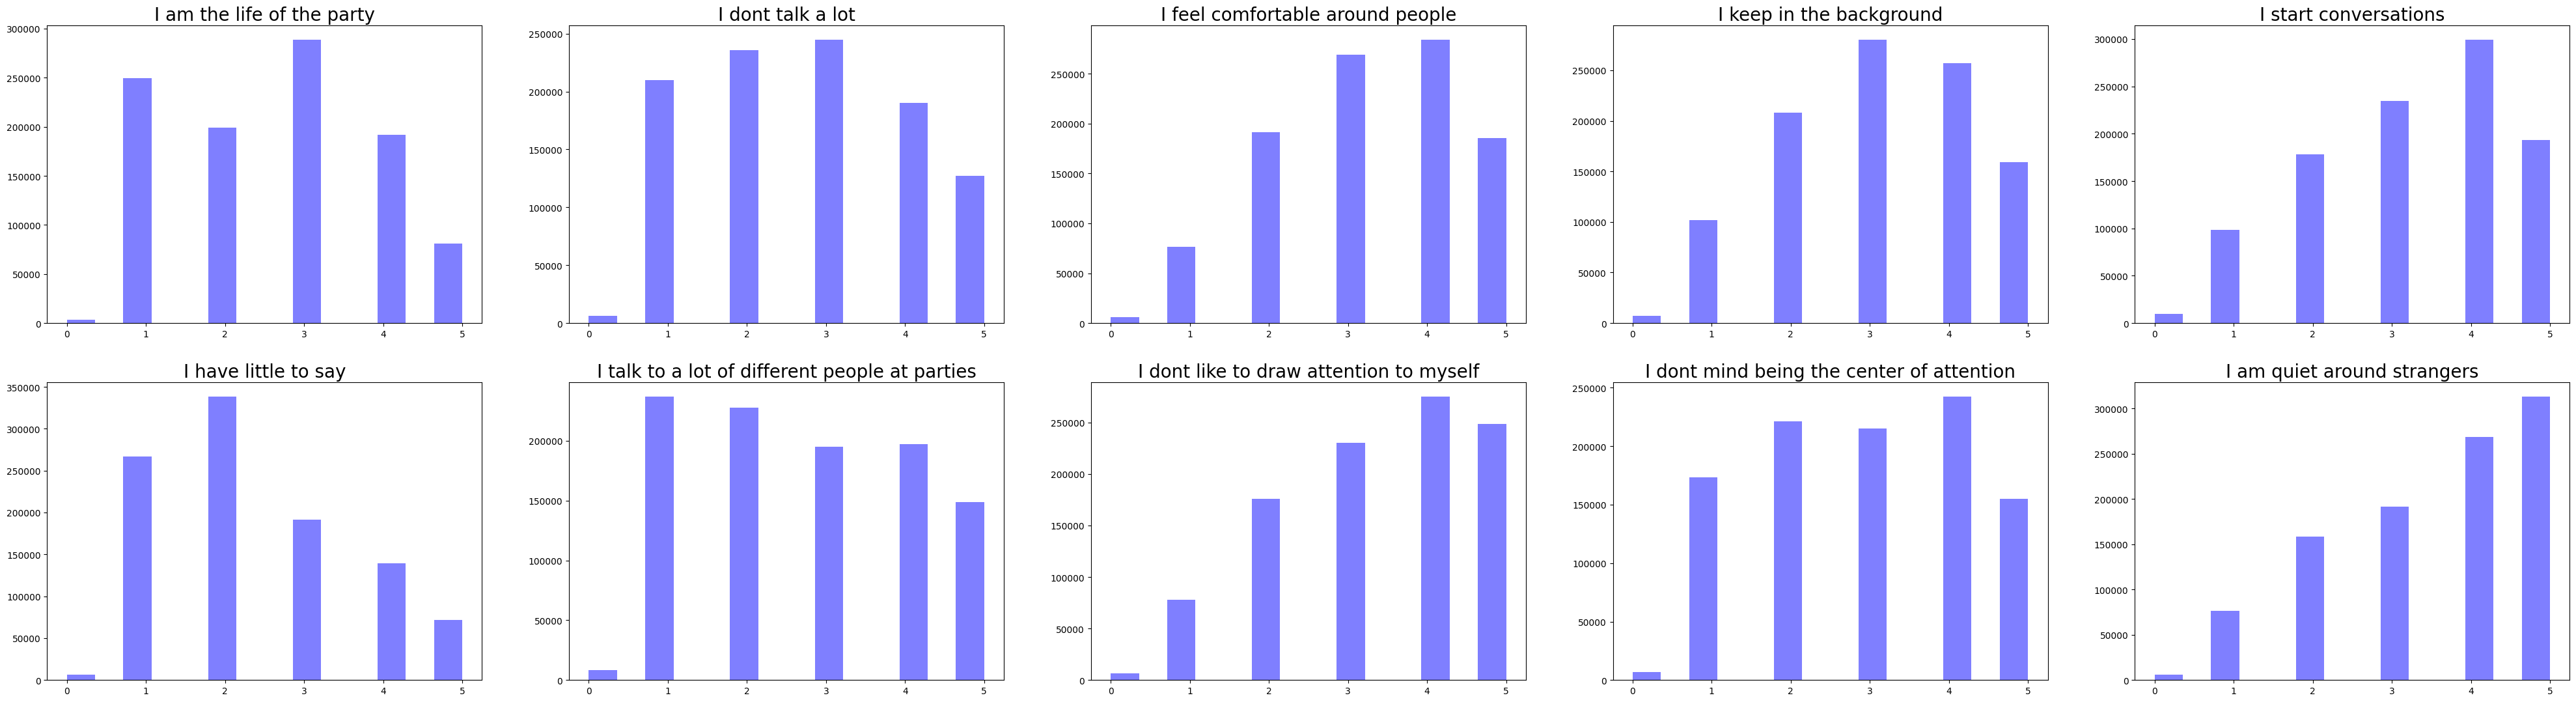

In [9]:
print('Q&As Related to Extroversion Personality')
vis_questions(EXT, ext_questions, 'blue')

Q&As Related to Neuroticism Personality


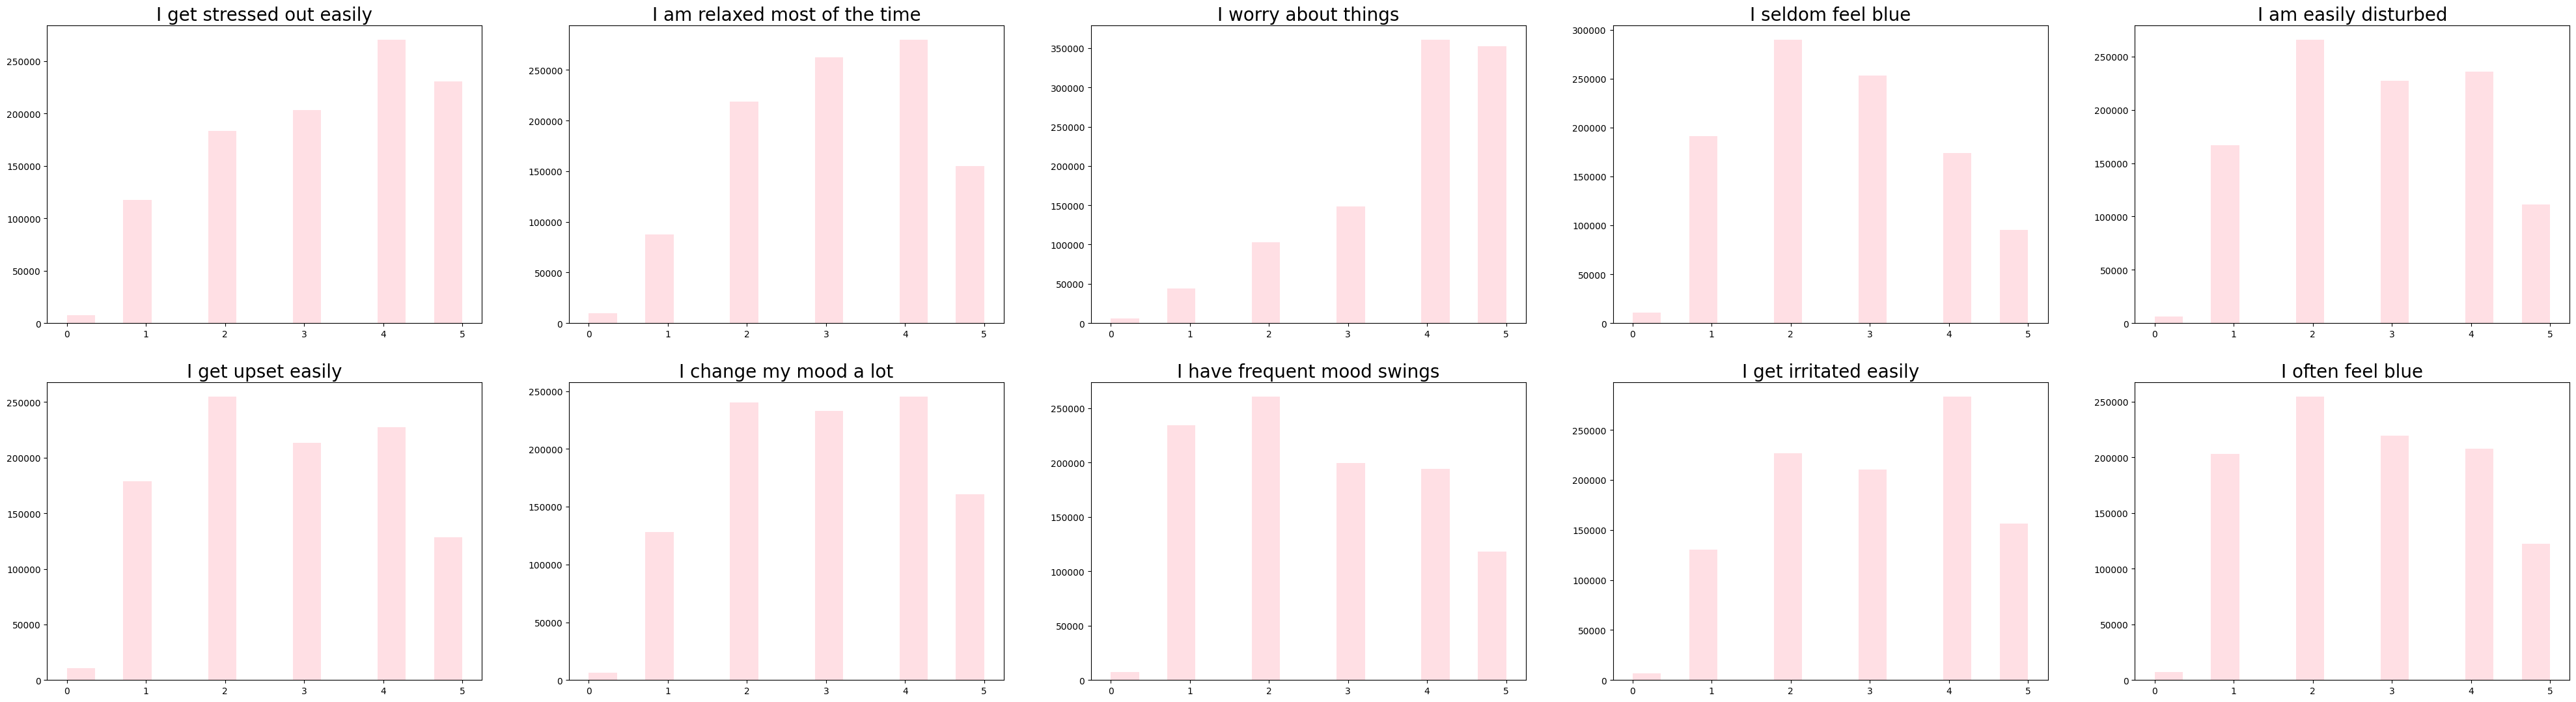

In [10]:
print('Q&As Related to Neuroticism Personality')
vis_questions(EST, est_questions, 'pink')

Q&As Related to Agreeable Personality


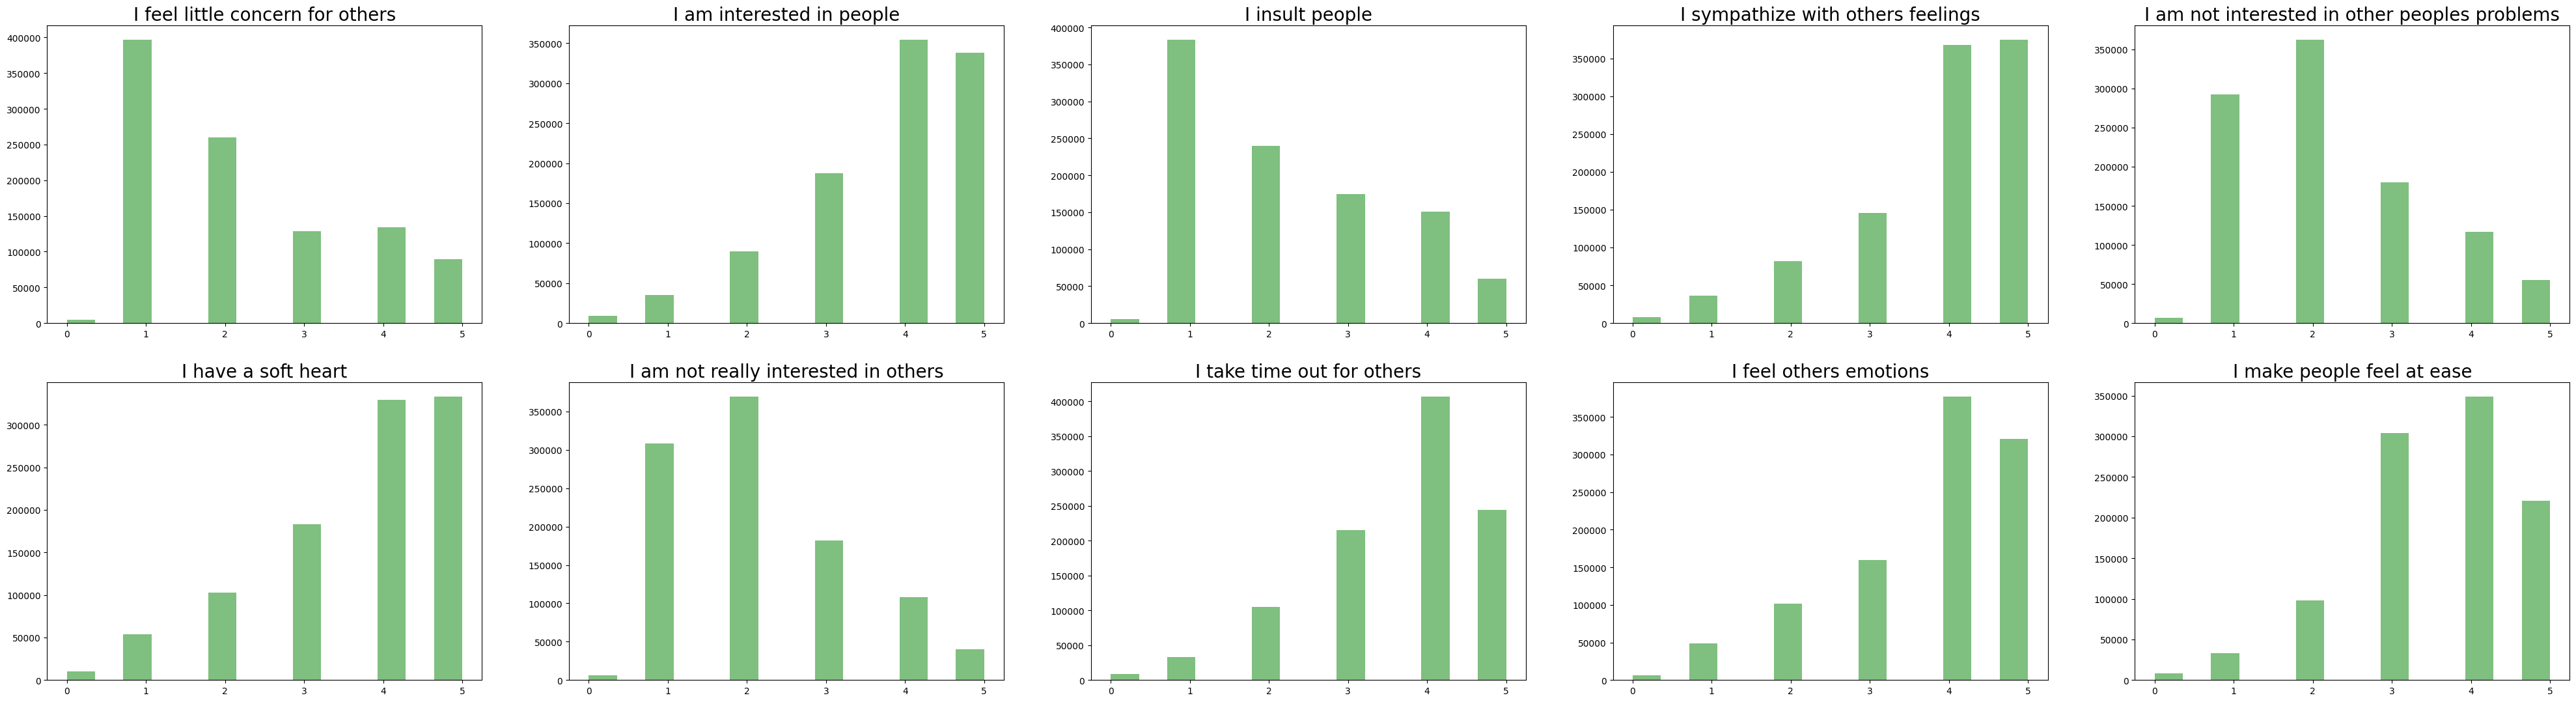

In [11]:
print('Q&As Related to Agreeable Personality')
vis_questions(AGR, agr_questions, 'green')

Q&As Related to Conscientious Personality


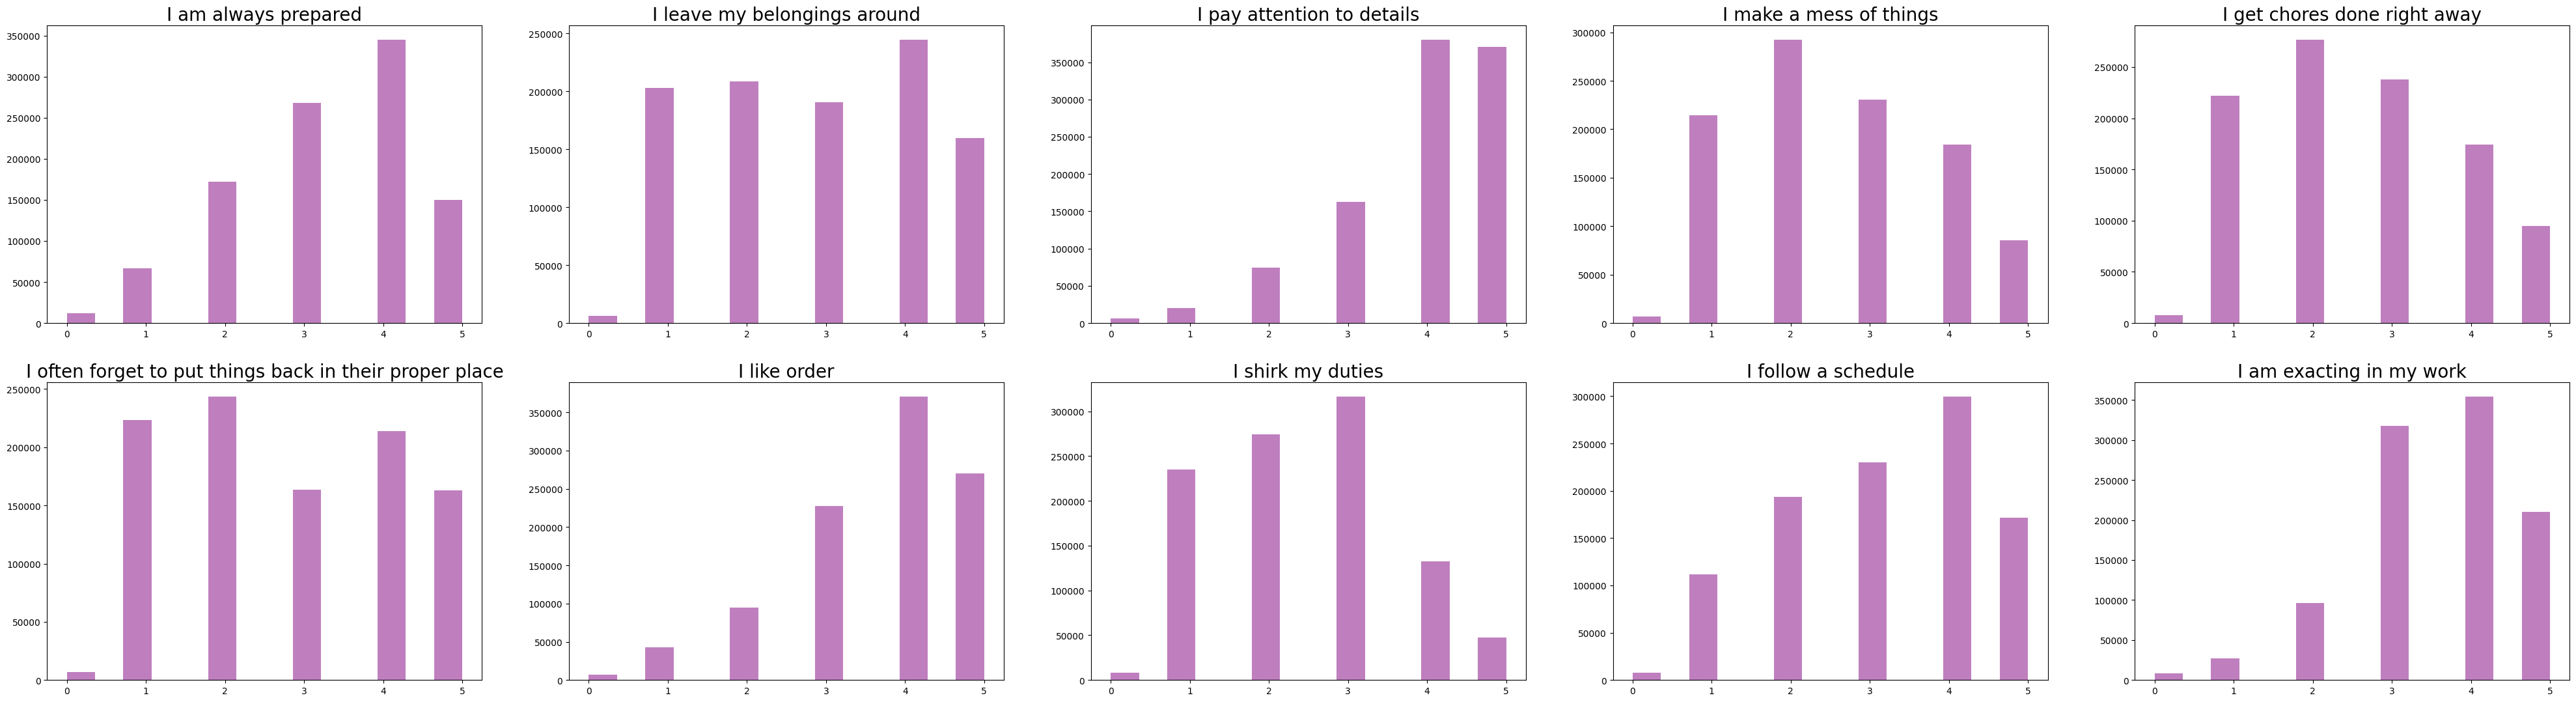

In [12]:
print('Q&As Related to Conscientious Personality')
vis_questions(CSN, csn_questions, 'purple')

Q&As Related to Open Personality


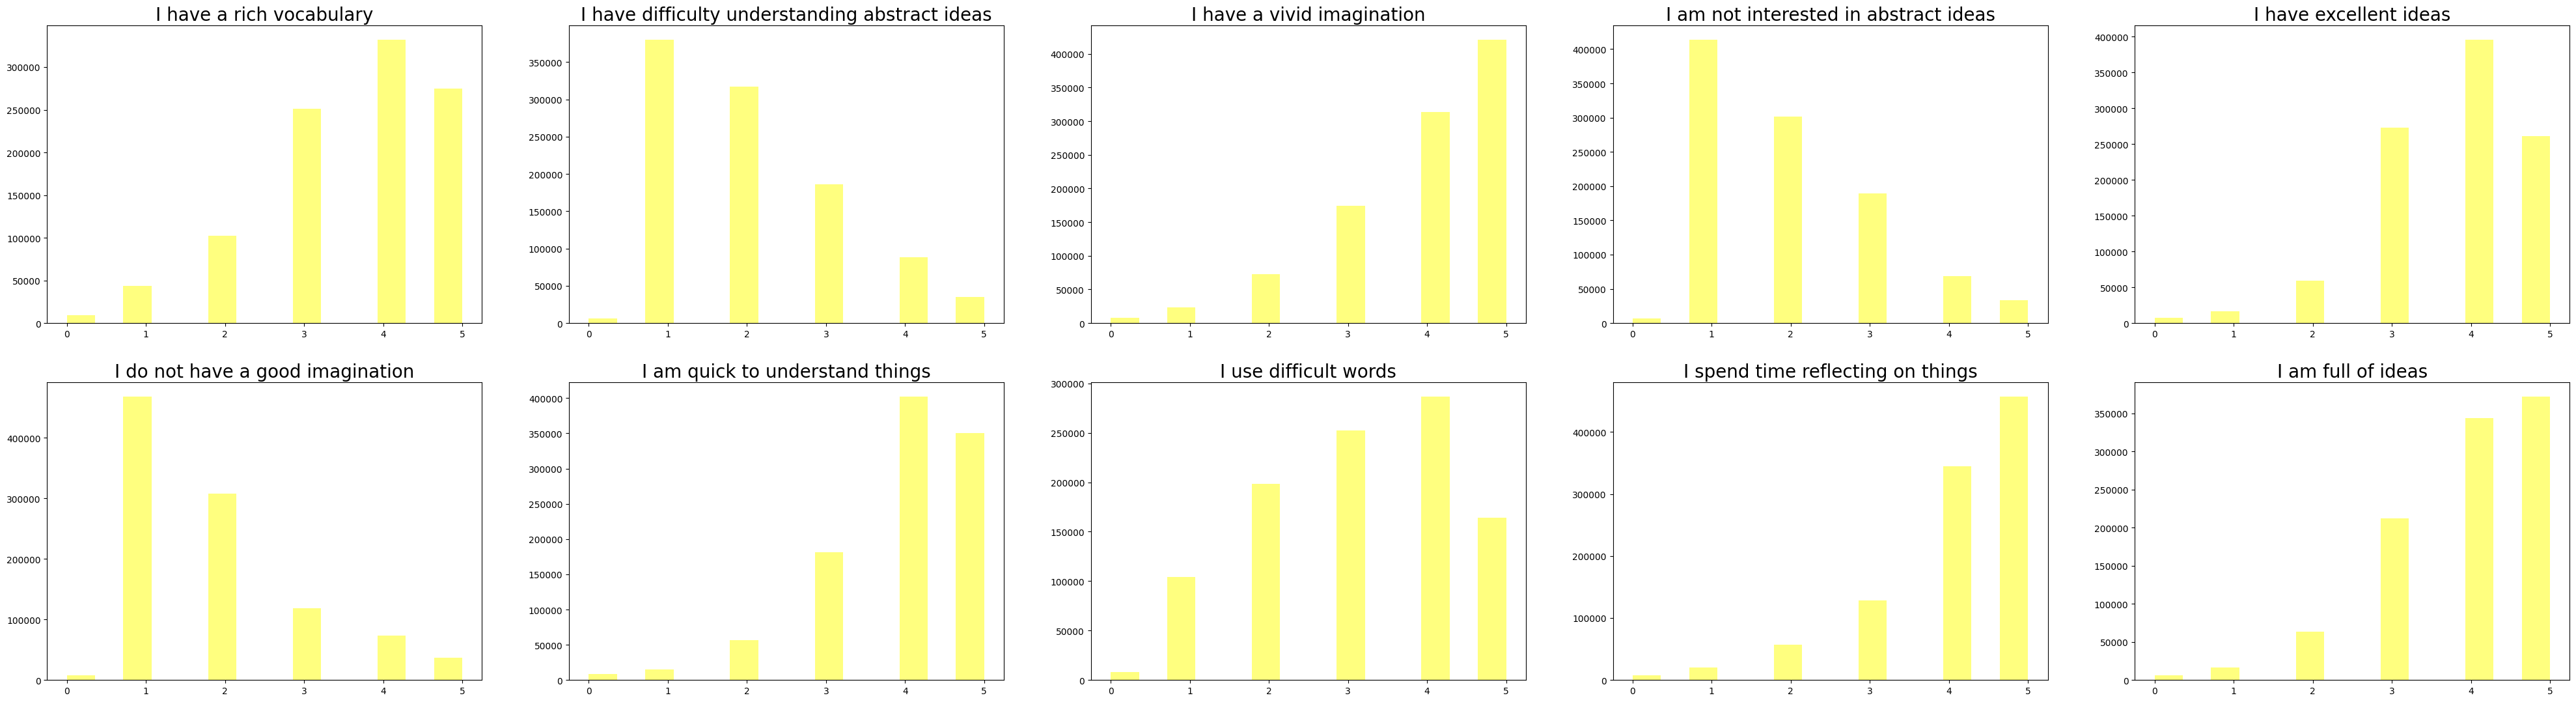

In [13]:
print('Q&As Related to Open Personality')
vis_questions(OPN, opn_questions, 'yellow')

In [14]:
df = data.drop('country', axis=1, inplace = True)

In [15]:
data.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,EST1,EST2,EST3,EST4,EST5,EST6,EST7,EST8,EST9,EST10,AGR1,AGR2,AGR3,AGR4,AGR5,AGR6,AGR7,AGR8,AGR9,AGR10,CSN1,CSN2,CSN3,CSN4,CSN5,CSN6,CSN7,CSN8,CSN9,CSN10,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,1.0,4.0,4.0,2.0,2.0,2.0,2.0,2.0,3.0,2.0,2.0,5.0,2.0,4.0,2.0,3.0,2.0,4.0,3.0,4.0,3.0,4.0,3.0,2.0,2.0,4.0,4.0,2.0,4.0,4.0,5.0,1.0,4.0,1.0,4.0,1.0,5.0,3.0,4.0,5.0
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,2.0,3.0,4.0,1.0,3.0,1.0,2.0,1.0,3.0,1.0,1.0,4.0,1.0,5.0,1.0,5.0,3.0,4.0,5.0,3.0,3.0,2.0,5.0,3.0,3.0,1.0,3.0,3.0,5.0,3.0,1.0,2.0,4.0,2.0,3.0,1.0,4.0,2.0,5.0,3.0
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,4.0,4.0,4.0,2.0,2.0,2.0,2.0,2.0,1.0,3.0,1.0,4.0,1.0,4.0,2.0,4.0,1.0,4.0,4.0,3.0,4.0,2.0,2.0,2.0,3.0,3.0,4.0,2.0,4.0,2.0,5.0,1.0,2.0,1.0,4.0,2.0,5.0,3.0,4.0,4.0
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,3.0,3.0,3.0,2.0,3.0,2.0,2.0,2.0,4.0,3.0,2.0,4.0,3.0,4.0,2.0,4.0,2.0,4.0,3.0,4.0,2.0,4.0,4.0,4.0,1.0,2.0,2.0,3.0,1.0,4.0,4.0,2.0,5.0,2.0,3.0,1.0,4.0,4.0,3.0,3.0
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,1.0,5.0,5.0,3.0,1.0,1.0,1.0,1.0,3.0,2.0,1.0,5.0,1.0,5.0,1.0,3.0,1.0,5.0,5.0,3.0,5.0,1.0,5.0,1.0,3.0,1.0,5.0,1.0,5.0,5.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,3.0,5.0,5.0


In [16]:
max_score = 5

negative_impact_questions = {
    "EXT": ["EXT2", "EXT4", "EXT6", "EXT8", "EXT10"],
    "EST": ["EST1", "EST3", "EST5", "EST6", "EST7", "EST8", "EST9", "EST10"],
    "AGR": ["AGR1", "AGR3", "AGR5", "AGR7"],
    "CSN": ["CSN2", "CSN4", "CSN6", "CSN8"],
    "OPN": ["OPN2", "OPN4", "OPN6"]
}

# Adjust scores for questions with negative impact
for trait, questions in negative_impact_questions.items():
    for question in questions:
        if question in data.columns:
            data[question] = (max_score + 1) - data[question]

# Define the questions for each trait
trait_questions = {
    "EXT": [f"EXT{i}" for i in range(1, 11)],
    "EST": [f"EST{i}" for i in range(1, 11)],
    "AGR": [f"AGR{i}" for i in range(1, 11)],
    "CSN": [f"CSN{i}" for i in range(1, 11)],
    "OPN": [f"OPN{i}" for i in range(1, 11)]
}


In [17]:
data.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,EST1,EST2,EST3,EST4,EST5,EST6,EST7,EST8,EST9,EST10,AGR1,AGR2,AGR3,AGR4,AGR5,AGR6,AGR7,AGR8,AGR9,AGR10,CSN1,CSN2,CSN3,CSN4,CSN5,CSN6,CSN7,CSN8,CSN9,CSN10,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10
0,4.0,5.0,5.0,4.0,5.0,5.0,5.0,4.0,4.0,5.0,5.0,4.0,2.0,2.0,4.0,4.0,4.0,4.0,3.0,4.0,4.0,5.0,4.0,4.0,4.0,3.0,4.0,4.0,3.0,4.0,3.0,2.0,3.0,4.0,2.0,2.0,4.0,4.0,4.0,4.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,3.0,4.0,5.0
1,3.0,1.0,3.0,2.0,3.0,3.0,2.0,1.0,1.0,1.0,4.0,3.0,2.0,1.0,3.0,5.0,4.0,5.0,3.0,5.0,5.0,4.0,5.0,5.0,5.0,5.0,3.0,4.0,5.0,3.0,3.0,4.0,5.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,1.0,4.0,4.0,4.0,3.0,5.0,4.0,2.0,5.0,3.0
2,2.0,3.0,4.0,2.0,3.0,4.0,1.0,3.0,2.0,1.0,2.0,4.0,2.0,2.0,4.0,4.0,4.0,4.0,5.0,3.0,5.0,4.0,5.0,4.0,4.0,4.0,5.0,4.0,4.0,3.0,4.0,4.0,2.0,4.0,3.0,3.0,4.0,4.0,4.0,2.0,5.0,5.0,2.0,5.0,4.0,4.0,5.0,3.0,4.0,4.0
3,2.0,4.0,2.0,3.0,4.0,4.0,2.0,2.0,1.0,2.0,3.0,3.0,3.0,2.0,3.0,4.0,4.0,4.0,2.0,3.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0,2.0,2.0,4.0,2.0,1.0,4.0,2.0,3.0,1.0,4.0,4.0,4.0,5.0,4.0,3.0,5.0,4.0,4.0,3.0,3.0
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,1.0,3.0,2.0,5.0,5.0,1.0,3.0,5.0,5.0,5.0,5.0,3.0,4.0,5.0,5.0,5.0,5.0,5.0,3.0,5.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,3.0,5.0,5.0


In [18]:
trait_questions = {
    "EXT": [f"EXT{i}" for i in range(1, 11)],
    "EST": [f"EST{i}" for i in range(1, 11)],
    "AGR": [f"AGR{i}" for i in range(1, 11)],
    "CSN": [f"CSN{i}" for i in range(1, 11)],
    "OPN": [f"OPN{i}" for i in range(1, 11)]
}

# Calculate percentages for each trait
for trait, questions in trait_questions.items():
    data[f"{trait}_Percentage"] = ((data[questions].sum(axis=1) / 50) * 100)

In [19]:
data.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,EST1,EST2,EST3,EST4,EST5,EST6,EST7,EST8,EST9,EST10,AGR1,AGR2,AGR3,AGR4,AGR5,AGR6,AGR7,AGR8,AGR9,AGR10,CSN1,CSN2,CSN3,CSN4,CSN5,CSN6,CSN7,CSN8,CSN9,CSN10,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10,EXT_Percentage,EST_Percentage,AGR_Percentage,CSN_Percentage,OPN_Percentage
0,4.0,5.0,5.0,4.0,5.0,5.0,5.0,4.0,4.0,5.0,5.0,4.0,2.0,2.0,4.0,4.0,4.0,4.0,3.0,4.0,4.0,5.0,4.0,4.0,4.0,3.0,4.0,4.0,3.0,4.0,3.0,2.0,3.0,4.0,2.0,2.0,4.0,4.0,4.0,4.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,3.0,4.0,5.0,92.0,72.0,78.0,64.0,90.0
1,3.0,1.0,3.0,2.0,3.0,3.0,2.0,1.0,1.0,1.0,4.0,3.0,2.0,1.0,3.0,5.0,4.0,5.0,3.0,5.0,5.0,4.0,5.0,5.0,5.0,5.0,3.0,4.0,5.0,3.0,3.0,4.0,5.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,1.0,4.0,4.0,4.0,3.0,5.0,4.0,2.0,5.0,3.0,40.0,70.0,88.0,74.0,70.0
2,2.0,3.0,4.0,2.0,3.0,4.0,1.0,3.0,2.0,1.0,2.0,4.0,2.0,2.0,4.0,4.0,4.0,4.0,5.0,3.0,5.0,4.0,5.0,4.0,4.0,4.0,5.0,4.0,4.0,3.0,4.0,4.0,2.0,4.0,3.0,3.0,4.0,4.0,4.0,2.0,5.0,5.0,2.0,5.0,4.0,4.0,5.0,3.0,4.0,4.0,50.0,68.0,84.0,68.0,82.0
3,2.0,4.0,2.0,3.0,4.0,4.0,2.0,2.0,1.0,2.0,3.0,3.0,3.0,2.0,3.0,4.0,4.0,4.0,2.0,3.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0,2.0,2.0,4.0,2.0,1.0,4.0,2.0,3.0,1.0,4.0,4.0,4.0,5.0,4.0,3.0,5.0,4.0,4.0,3.0,3.0,52.0,62.0,76.0,50.0,78.0
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,1.0,3.0,2.0,5.0,5.0,1.0,3.0,5.0,5.0,5.0,5.0,3.0,4.0,5.0,5.0,5.0,5.0,5.0,3.0,5.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,3.0,5.0,5.0,58.0,82.0,92.0,96.0,96.0


In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1013481 entries, 0 to 1015340
Data columns (total 55 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   EXT1            1013481 non-null  float64
 1   EXT2            1013481 non-null  float64
 2   EXT3            1013481 non-null  float64
 3   EXT4            1013481 non-null  float64
 4   EXT5            1013481 non-null  float64
 5   EXT6            1013481 non-null  float64
 6   EXT7            1013481 non-null  float64
 7   EXT8            1013481 non-null  float64
 8   EXT9            1013481 non-null  float64
 9   EXT10           1013481 non-null  float64
 10  EST1            1013481 non-null  float64
 11  EST2            1013481 non-null  float64
 12  EST3            1013481 non-null  float64
 13  EST4            1013481 non-null  float64
 14  EST5            1013481 non-null  float64
 15  EST6            1013481 non-null  float64
 16  EST7            1013481 non-null  float64

In [21]:
data.describe()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,EST1,EST2,EST3,EST4,EST5,EST6,EST7,EST8,EST9,EST10,AGR1,AGR2,AGR3,AGR4,AGR5,AGR6,AGR7,AGR8,AGR9,AGR10,CSN1,CSN2,CSN3,CSN4,CSN5,CSN6,CSN7,CSN8,CSN9,CSN10,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10,EXT_Percentage,EST_Percentage,AGR_Percentage,CSN_Percentage,OPN_Percentage
count,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06,1.013481e+06
mean,2.648098e+00,3.226901e+00,3.288378e+00,2.859436e+00,3.276977e+00,3.598918e+00,2.771755e+00,2.585206e+00,2.963757e+00,2.443545e+00,2.714026e+00,3.165069e+00,2.153544e+00,2.663759e+00,3.156918e+00,3.158862e+00,2.949605e+00,3.316528e+00,2.911523e+00,3.226517e+00,3.744681e+00,3.831127e+00,3.740046e+00,3.927512e+00,3.729162e+00,3.743069e+00,3.804219e+00,3.689405e+00,3.789124e+00,3.592338e+00,3.297995e+00,3.069708e+00,3.975277e+00,3.382125e+00,2.625835e+00,3.168181e+00,3.698181e+00,3.534711e+00,3.200716e+00,3.590585e+00,3.654625e+00,3.924060e+00,4.000056e+00,4.000103e+00,3.792886e+00,4.105377e+00,3.976374e+00,3.182446e+00,4.122980e+00,3.958436e+00,5.932594e+01,5.883270e+01,7.518137e+01,6.708663e+01,7.743469e+01
std,1.264409e+00,1.323945e+00,1.215004e+00,1.237448e+00,1.277598e+00,1.225719e+00,1.400337e+00,1.271915e+00,1.346035e+00,1.305234e+00,1.345606e+00,1.228270e+00,1.163360e+00,1.252995e+00,1.273887e+00,1.326561e+00,1.293009e+00,1.343043e+00,1.297135e+00,1.323153e+00,1.339973e+00,1.140579e+00,1.277313e+00,1.127682e+00,1.171196e+00,1.222426e+00,1.120312e+00,1.095534e+00,1.166742e+00,1.080782e+00,1.176792e+00,1.390058e+00,1.044728e+00,1.251802e+00,1.274596e+00,1.416194e+00,1.128071e+00,1.140959e+00,1.276234e+00,1.053186e+00,1.157159e+00,1.112596e+00,1.097170e+00,1.090246e+00,9.923940e-01,1.104132e+00,1.008499e+00,1.255370e+00,1.041223e+00,1.034492e+00,1.808935e+01,1.722594e+01,1.464569e+01,1.474227e+01,1.291831e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+01,1.600000e+01,1.600000e+01,1.200000e+01,1.800000e+01
25%,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,2.000000e+00,3.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,2.000000e+00,4.000000e+00,3.000000e+00,4.600000e+01,4.600000e+01,6.600000e+01,5.600000e+01,6.800000e+01
50%,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,4.

In [22]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Exclude the percentage columns
columns_to_normalize = [col for col in data.columns if 'Percentage' not in col]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Normalize the selected columns
data[columns_to_normalize] = scaler.fit_transform(data[columns_to_normalize])



In [23]:
data.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,EST1,EST2,EST3,EST4,EST5,EST6,EST7,EST8,EST9,EST10,AGR1,AGR2,AGR3,AGR4,AGR5,AGR6,AGR7,AGR8,AGR9,AGR10,CSN1,CSN2,CSN3,CSN4,CSN5,CSN6,CSN7,CSN8,CSN9,CSN10,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10,EXT_Percentage,EST_Percentage,AGR_Percentage,CSN_Percentage,OPN_Percentage
0,0.8,0.8,1.0,0.6,1.0,0.8,1.0,0.6,0.8,0.8,0.8,0.8,0.2,0.4,0.6,0.6,0.6,0.6,0.4,0.6,0.6,1.0,0.6,0.8,0.6,0.6,0.6,0.8,0.6,0.8,0.6,0.2,0.6,0.6,0.4,0.2,0.8,0.6,0.8,0.8,1.0,0.8,0.8,0.8,0.8,0.8,1.0,0.6,0.8,1.0,92.0,72.0,78.0,64.0,90.0
1,0.6,0.0,0.6,0.2,0.6,0.4,0.4,0.0,0.2,0.0,0.6,0.6,0.2,0.2,0.4,0.8,0.6,0.8,0.4,0.8,0.8,0.8,0.8,1.0,0.8,1.0,0.4,0.8,1.0,0.6,0.6,0.6,1.0,0.4,0.6,0.8,0.6,0.4,1.0,0.6,0.2,0.6,0.8,0.6,0.6,0.8,0.8,0.4,1.0,0.6,40.0,70.0,88.0,74.0,70.0
2,0.4,0.4,0.8,0.2,0.6,0.6,0.2,0.4,0.4,0.0,0.2,0.8,0.2,0.4,0.6,0.6,0.6,0.6,0.8,0.4,0.8,0.8,0.8,0.8,0.6,0.8,0.8,0.8,0.8,0.6,0.8,0.6,0.4,0.6,0.6,0.4,0.8,0.6,0.8,0.4,1.0,0.8,0.4,0.8,0.8,0.6,1.0,0.6,0.8,0.8,50.0,68.0,84.0,68.0,82.0
3,0.4,0.6,0.4,0.4,0.8,0.6,0.4,0.2,0.2,0.2,0.4,0.6,0.4,0.4,0.4,0.6,0.6,0.6,0.2,0.4,0.6,0.8,0.4,0.8,0.6,0.8,0.6,0.8,0.6,0.8,0.4,0.2,0.8,0.2,0.2,0.6,0.4,0.4,0.2,0.8,0.8,0.6,1.0,0.6,0.6,0.8,0.8,0.8,0.6,0.6,52.0,62.0,76.0,50.0,78.0
4,0.6,0.4,0.6,0.4,1.0,0.4,0.6,0.0,0.6,0.2,0.8,1.0,0.0,0.6,0.8,0.8,0.8,0.8,0.4,0.6,0.8,1.0,0.8,1.0,0.8,0.6,0.8,1.0,1.0,0.6,1.0,0.8,1.0,0.8,0.6,0.8,1.0,0.8,1.0,1.0,1.0,0.8,1.0,0.8,1.0,0.8,1.0,0.6,1.0,1.0,58.0,82.0,92.0,96.0,96.0


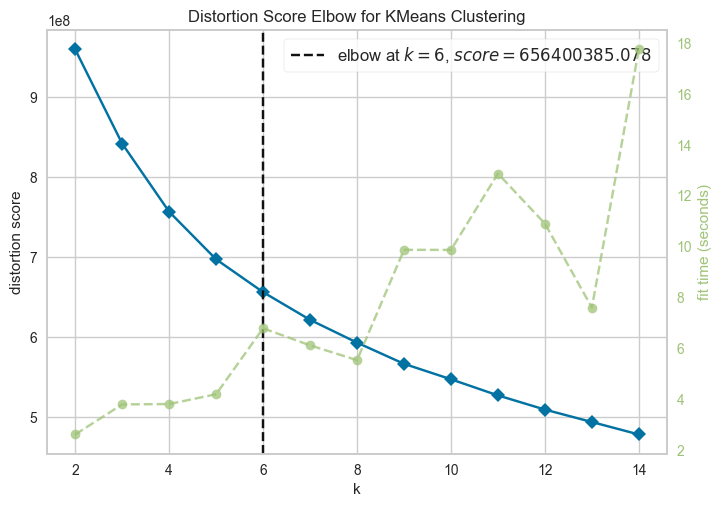

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [24]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

kmeans = KMeans()
visualizer = KElbowVisualizer(kmeans, k=(2, 15))

# Fit the visualizer with the data and display the plot
visualizer.fit(data) 
visualizer.show()


In [25]:
# Creating K-means Cluster Model
from sklearn.cluster import KMeans

# I define 6 clusters and fit my model
kmeans = KMeans(n_clusters=6)
k_fit = kmeans.fit(data)

In [26]:
pd.options.display.max_columns = 10
predictions = k_fit.labels_
data['Clusters'] = predictions
data.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,...,EST_Percentage,AGR_Percentage,CSN_Percentage,OPN_Percentage,Clusters
0,0.8,0.8,1.0,0.6,1.0,...,72.0,78.0,64.0,90.0,0
1,0.6,0.0,0.6,0.2,0.6,...,70.0,88.0,74.0,70.0,2
2,0.4,0.4,0.8,0.2,0.6,...,68.0,84.0,68.0,82.0,2
3,0.4,0.6,0.4,0.4,0.8,...,62.0,76.0,50.0,78.0,1
4,0.6,0.4,0.6,0.4,1.0,...,82.0,92.0,96.0,96.0,0


In [27]:
data.tail()

,EXT1,EXT2,EXT3,EXT4,EXT5,...,EST_Percentage,AGR_Percentage,CSN_Percentage,OPN_Percentage,Clusters
1015336,0.8,0.6,0.8,0.4,0.8,...,54.0,76.0,62.0,66.0,1
1015337,0.8,0.4,0.8,0.4,0.6,...,32.0,78.0,56.0,90.0,3
1015338,0.8,0.6,0.8,0.4,1.0,...,62.0,70.0,38.0,96.0,3
1015339,0.4,0.2,0.6,0.2,0.4,...,50.0,74.0,76.0,82.0,2
1015340,0.8,0.6,0.8,0.6,0.8,...,62.0,84.0,56.0,94.0,3


In [28]:
df = data
df.Clusters.value_counts()

Clusters
0    199938
3    187919
2    181338
4    175143
1    148841
5    120302
Name: count, dtype: int64

In [29]:
pd.options.display.max_columns = 150
df.groupby('Clusters').mean()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,EST1,EST2,EST3,EST4,EST5,EST6,EST7,EST8,EST9,EST10,AGR1,AGR2,AGR3,AGR4,AGR5,AGR6,AGR7,AGR8,AGR9,AGR10,CSN1,CSN2,CSN3,CSN4,CSN5,CSN6,CSN7,CSN8,CSN9,CSN10,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10,EXT_Percentage,EST_Percentage,AGR_Percentage,CSN_Percentage,OPN_Percentage
Clusters,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.686317,0.603299,0.863597,0.548570,0.847403,0.667261,0.764403,0.434986,0.745375,0.484442,0.541106,0.773649,0.373324,0.668502,0.587548,0.625266,0.583707,0.670095,0.581964,0.660685,0.628486,0.886018,0.638152,0.854953,0.631447,0.777411,0.682094,0.824035,0.826071,0.841362,0.755419,0.494761,0.852407,0.626591,0.637792,0.553508,0.787684,0.620781,0.728616,0.787460,0.788929,0.658521,0.826661,0.650387,0.839154,0.678137,0.870733,0.658423,0.833126,0.866993,76.456522,76.658454,83.900289,76.450200,82.710640
1,0.560355,0.475382,0.677946,0.419258,0.647174,0.494282,0.566191,0.369905,0.593471,0.333221,0.429895,0.684080,0.323715,0.565442,0.461632,0.505122,0.458179,0.536186,0.448153,0.539710,0.472661,0.708810,0.526595,0.703415,0.505182,0.678067,0.533951,0.669459,0.669426,0.661369,0.579494,0.392682,0.680061,0.457019,0.475388,0.394663,0.638863,0.467190,0.566187,0.615511,0.562016,0.456201,0.638491,0.475974,0.628579,0.499760,0.665208,0.475309,0.660448,0.636014,61.371853,65.521140,69.289362,60.670568,62.979999
2,0.422766,0.340195,0.599332,0.258500,0.586060,0.460485,0.437337,0.199035,0.468029,0.164415,0.256932,0.580895,0.140497,0.491941,0.401266,0.387219,0.366156,0.448713,0.355296,0.405324,0.637090,0.802909,0.652393,0.884536,0.619262,0.844590,0.610504,0.809767,0.854540,0.754980,0.776913,0.551171,0.879839,0.582435,0.652666,0.580852,0.849730,0.600409,0.776941,0.798769,0.737463,0.584563,0.805558,0.602960,0.759834,0.625268,0.812242,0.625446,0.871582,0.784557,49.361524,54.342399,82.705721,78.497259,78.094729
3,0.697577,0.636087,0.768940,0.522047,0.823622,0.662022,0.742954,0.465011,0.766777,0.427301,0.223843,0.560654,0.137983,0.458488,0.339497,0.301054,0.236908,0.305349,0.267954,0.349292,0.596898,0.864061,0.494291,0.849148,0.616439,0.807721,0.645160,0.788199,0.837996,0.779304,0.590023,0.285339,0.771193,0.362729,0.440970,0.307234,0.690815,0.441500,0.582275,0.695744,0.779371,0.613762,0.872359,0.640636,0.811304,0.674733,0.813734,0.702704,0.861100,0.864181,75.123388,47.810227,80.792160,59.678223,82.338827
4,0.359676,0.271043,0.443829,0.185472,0.455089,0.356882,0.349649,0.179697,0.430846,0.101668,0.142360,0.483318,0.094501,0.418503,0.279374,0.222703,0.197213,0.242477,0.191801,0.206163,0.495649,0.666733,0.471644,0.754357,0.478751,0.756261,0.449746,0.677055,0.721345,0.606245,0.543363,0.310309,0.749155,0.291815,0.401391,0.282601,0.695296,0.375373,0.535396,0.646102,0.700299,0.524296,0.812040,0.572783,0.685795,0.581185,0.734665,0.633786,0.852968,0.745017,41.338506,40.784125,68.777856,56.308000,74.428347
5,0.377287,0.260273,0.515837,0.227388,0.479809,0.410593,0.370393,0.202311,0.490080,0.151507,0.512573,0.745629,0.357743,0.610545,0.544653,0.595167,0.538799,0.619689,0.465688,0.528939,0.380878,0.574897,0.462435,0.568285,0.330523,0.539903,0.347783,0.580945,0.535863,0.598178,0.700529,0.450832,0.818314,0.537434,0.519112,0.478059,0.759326,0.519810,0.621293,0.748039,0.802562,0.664687,0.816673,0.641567,0.807202,0.644275,0.864619,0.716603,0.844355,0.824588,44.854782,71.194244,57.196888,69.527473,82.271317


In [30]:
col_list = list(df)
ext = col_list[0:10]
est = col_list[10:20]
agr = col_list[20:30]
csn = col_list[30:40]
opn = col_list[40:50]

data_sums = pd.DataFrame()
data_sums['extroversion'] = df[ext].sum(axis=1)/10
data_sums['neurotic'] = df[est].sum(axis=1)/10
data_sums['agreeable'] = df[agr].sum(axis=1)/10
data_sums['conscientious'] = df[csn].sum(axis=1)/10
data_sums['openness'] = df[opn].sum(axis=1)/10
data_sums['clusters'] = predictions
data_sums.groupby('clusters').mean()



,extroversion,neurotic,agreeable,conscientious,openness
clusters,,,,,
0,0.664565,0.606585,0.759003,0.684502,0.767106
1,0.513719,0.495211,0.612894,0.526706,0.569800
2,0.393615,0.383424,0.747057,0.704973,0.720947
3,0.651234,0.318102,0.727922,0.516782,0.763388
4,0.313385,0.247841,0.607779,0.483080,0.684283
5,0.348548,0.551942,0.491969,0.615275,0.762713


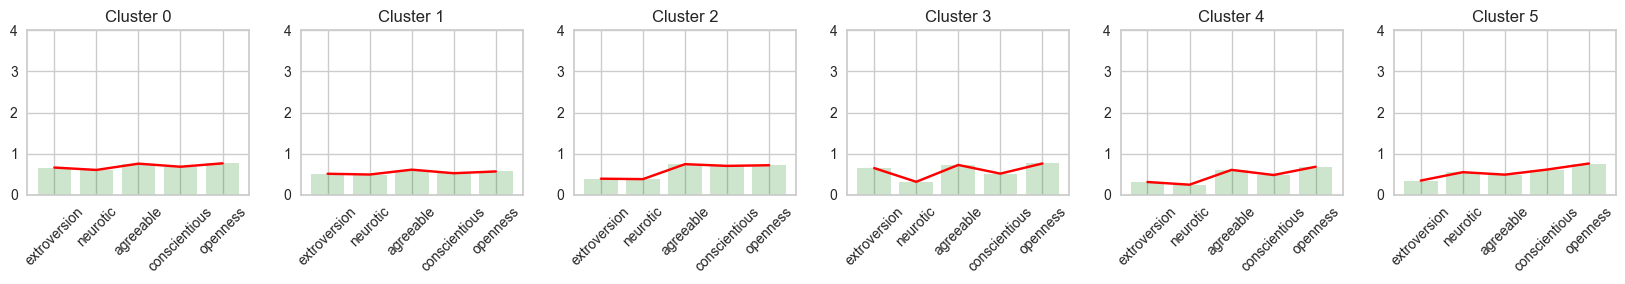

In [31]:
import matplotlib.pyplot as plt

dataclusters = data_sums.groupby('clusters').mean()

plt.figure(figsize=(22, 3))
for i, cluster in enumerate(dataclusters.index):
    plt.subplot(1, 8, i + 1)
    plt.bar(dataclusters.columns, dataclusters.iloc[i, :], color='green', alpha=0.2)
    plt.plot(dataclusters.columns, dataclusters.iloc[i, :], color='red')
    plt.title('Cluster ' + str(cluster))
    plt.xticks(rotation=45)
    plt.ylim(0, 4)

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_fit = pca.fit_transform(df)

df_pca = pd.DataFrame(data=pca_fit, columns=['PCA1', 'PCA2'])
df_pca['Clusters'] = predictions
df_pca.head()

plt.figure(figsize=(8,8))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Clusters', palette='Set2', alpha=0.8)
plt.title('Personality Clusters after PCA');

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

def vis_questions_heatmap(groupname, questions, data, cmap="YlGnBu"):
    # Prepare data for the heatmap
    # Ensure each column is in groupname and exists in data
    data_subset = data[groupname]

    # Calculate the average response for each question
    heatmap_data = data_subset.apply(lambda x: x.value_counts().sort_index(), axis=0).fillna(0)

    # Rename columns using questions dictionary for readability
    heatmap_data.columns = [questions[col] for col in groupname]

    # Plotting the heatmap
    plt.figure(figsize=(10, 8))  # Adjust size for readability
    sns.heatmap(heatmap_data.T, cmap=cmap, annot=True, fmt=".0f", linewidths=0.5, 
                cbar_kws={'label': 'Frequency'})  # Display counts per score bin

    # Customizations
    plt.xlabel("Response Scores", fontsize=12, color="#333333")
    plt.ylabel("Questions", fontsize=12, color="#333333")
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    
    plt.tight_layout()
    plt.show()




In [ ]:
# Call the function with ext_questions as the label dictionary
vis_questions_heatmap(EXT, ext_questions, data)

In [ ]:
vis_questions_heatmap(EST, est_questions, data)

In [ ]:
vis_questions_heatmap(AGR, agr_questions, data)

In [ ]:
vis_questions_heatmap(CSN, csn_questions, data)

In [ ]:
vis_questions_heatmap(OPN, opn_questions, data)

In [ ]:
data.head()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor

def process_group(data, group):
    # Define feature columns and target column
    feature_cols = [f"{group}{i}" for i in range(1, 11)]
    target_col = f"{group}_Percentage"
    
    # Check if columns exist in the dataset
    if all(col in data.columns for col in feature_cols + [target_col]):
        # Create feature matrix X and target vector y
        X = data[feature_cols]
        y = data[target_col]
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Define models
        models = {
            'Linear Regression': LinearRegression(),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
            'Decision Tree': DecisionTreeRegressor(random_state=42),
            'Neural Network': MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=1000, random_state=42)
        }
        
        # Results dictionary for the current group
        group_results = {'Group': [], 'Model': [], 'RMSE': [], 'R-squared': []}
        
        # Train and evaluate each model
        for model_name, model in models.items():
            # Train the model
            model.fit(X_train, y_train)

            # Make predictions
            y_pred = model.predict(X_test)

            # Calculate metrics
            mse = mean_squared_error(y_test, y_pred)
            rmse = mse ** 0.5  # Root Mean Squared Error
            r2 = r2_score(y_test, y_pred)  # R-squared score

            # Store results
            group_results['Group'].append(group)
            group_results['Model'].append(model_name)
            group_results['RMSE'].append(rmse)
            group_results['R-squared'].append(r2)
        
        # Convert results to DataFrame and return
        return pd.DataFrame(group_results)
    else:
        print(f"Columns for group {group} are missing in the dataset.")
        return pd.DataFrame()


In [ ]:
# Assuming `data` is your dataset
group = 'EXT'  # Change this to 'EST', 'AGR', 'CSN', or 'OPN' for other groups
results_df = process_group(data, group)

# Print the results for the group
print(results_df)

# Optionally save results to a CSV file
results_df.to_csv(f'{group}_results.csv', index=False)


In [ ]:
# Assuming `data` is your dataset
group = 'EST'  # Change this to 'EST', 'AGR', 'CSN', or 'OPN' for other groups
results_df = process_group(data, group)

# Print the results for the group
print(results_df)

# Optionally save results to a CSV file
results_df.to_csv(f'{group}_results.csv', index=False)

In [ ]:
# Assuming `data` is your dataset
group = 'AGR'  # Change this to 'EST', 'AGR', 'CSN', or 'OPN' for other groups
results_df = process_group(data, group)

# Print the results for the group
print(results_df)

# Optionally save results to a CSV file
results_df.to_csv(f'{group}_results.csv', index=False)

In [ ]:
# Assuming `data` is your dataset
group = 'CSN'  # Change this to 'EST', 'AGR', 'CSN', or 'OPN' for other groups
results_df = process_group(data, group)

# Print the results for the group
print(results_df)

# Optionally save results to a CSV file
results_df.to_csv(f'{group}_results.csv', index=False)

In [ ]:
# Assuming `data` is your dataset
group = 'OPN'  # Change this to 'EST', 'AGR', 'CSN', or 'OPN' for other groups
results_df = process_group(data, group)

# Print the results for the group
print(results_df)

# Optionally save results to a CSV file
results_df.to_csv(f'{group}_results.csv', index=False)

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
import joblib

# Assuming you have data for each trait like y_ext, y_est, y_agr, y_csn, y_opn
# and corresponding X (feature matrix) for all traits.

# List of traits
traits = ['EXT', 'EST', 'AGR', 'CSN', 'OPN']

# Loop through each trait
for trait in traits:
    
    feature_cols = [f"{group}{i}" for i in range(1, 11)]
    target_col = f"{group}_Percentage"
    
    if all(col in data.columns for col in feature_cols + [target_col]):
        # Create feature matrix X and target vector y
        X = data[feature_cols]
        y = data[target_col]
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
    model = MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=1000, random_state=42)
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Save the trained model with the trait name
    model_filename = f'neural_network_model_{trait.lower()}.pkl'  # Saving as .pkl file
    joblib.dump(model, model_filename)
    
    print(f"Model for {trait} trained and saved as {model_filename}.")


In [ ]:
import numpy as np
import pandas as pd

# Define the number of rows for the new data (e.g., 5 rows)
n_samples = 5

# Generate random data that matches the feature columns (e.g., EXT1 to EXT10)
# You can adjust the range or distribution based on your data
X_new_ext = np.random.rand(n_samples, 10)  # 10 features for EXT1 to EXT10

# Convert it into a DataFrame with the appropriate column names
X_new_ext = pd.DataFrame(X_new_ext, columns=[f'EXT{i}' for i in range(1, 11)])

# Print the new data
print(X_new_ext)


In [ ]:

# Load the trained model for EXT
model_ext = joblib.load('neural_network_model_ext.pkl')

# Use the new data (X_new_ext) to predict the target value
y_pred_ext = model_ext.predict(X_new_ext)

# Print the predicted results
print("Predicted EXT Percentages:", y_pred_ext)

